<a href="https://colab.research.google.com/github/Ytterbium171/yb2-fluoresence/blob/main/zeeman_slower_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

created by Rui Wu @ arw131072

In [13]:
import numpy as np
from scipy.constants import hbar, c, pi, e, m_e
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [14]:
class ZeemanSlower:
    def __init__(self, gamma, k, mass, mu_eff, wavelength):
        """
        Initialize Zeeman Slower parameters
        """
        self.gamma = gamma
        self.k = k
        self.mass = mass
        self.mu_eff = mu_eff
        self.wavelength = wavelength
        self.gamma_hz = gamma / (2 * np.pi)
        self.hbar = hbar
        self.c = c

    def scattering_force(self, v, z, delta_laser, B_func, s):
        """
        Radiation pressure force
        """
        B = B_func(z)
        delta_total = delta_laser + self.k * v - (self.mu_eff * B / self.hbar)
        scattering_rate = (self.gamma / 2) * (s / (1 + s + (2 * delta_total / self.gamma)**2))
        force = -self.hbar * self.k * scattering_rate

        return force, delta_total, scattering_rate

    def saturation_param(self, z, rho, P_L, wL):
        """
        Saturation parameter s(z, rho)
        """
        I_sat = (np.pi * self.hbar * self.c * self.gamma) / (3 * self.wavelength**3)
        z_R = np.pi * wL**2 / self.wavelength  # rayleigh length
        w_z = wL * np.sqrt(1 + (z / z_R)**2)
        I_0 = 2 * P_L / (np.pi * wL**2)
        I_rho_z = I_0 * (wL / w_z)**2 * np.exp(-2 * rho**2 / w_z**2)
        s = I_rho_z / I_sat
        return s

    def create_B_field_function(self, slower_length, v_i, v_f, delta_laser):
        """
        B-field function with pre-set parameters
        B_func : callable function that takes z and returns B(z)
        """
        def B_func(z):
            return self.ideal_B_field(z, slower_length, v_i, v_f, delta_laser)
        return B_func

    def ideal_B_field(self, z, slower_length, v_i, v_f, delta_laser):
        """
        ideal B-field profile for constant deceleration
        returns B_z: float or array, magnetic field [T] at z
        """
        # Handle both single vals and arrays
        if isinstance(z, np.ndarray):
            B_z = np.zeros_like(z)
            mask = (z >= 0) & (z <= slower_length)
            B_z[mask] = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z[mask] / slower_length)
            )
            B_z[z > slower_length] = (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
        else:
            if z < 0 or z > slower_length:
                return (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
            B_z = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z / slower_length)
            )

        return B_z

    def simulate_slower(self, z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.05, n_points=1000):
        """
        Simulate atom trajectory through Zeeman slower
        """
        initial_state = [z0, v0]  # [position, velocity]
        t = np.linspace(0, t_max, n_points)

        # lists for dynamic storage during simulation
        force_list = []
        delta_total_list = []
        scattering_rate_list = []
        s_list = []
        B_list = []
        z_list = []
        v_list = []
        t_list = []
        rho_list = []

        self.has_exited = False
        self.exit_time = -1
        self.exit_position = -1
        self.exit_velocity = -1

        def motion_equation(state, t):
            z, v = state

            # If atom has left slower, stop simulation
            if z >= slower_length and not self.has_exited:
                self.has_exited = True
                self.exit_time = t
                self.exit_position = z
                self.exit_velocity = v
                raise StopIteration("Atom exited Zeeman Slower")

            # calculate saturation parameter
            s_val = self.saturation_param(z, rho0, P_L, wL)

            # calculate force and acceleration
            force, delta_total, scattering_rate = self.scattering_force(v, z, delta_laser, B_func, s_val)
            acceleration = force / self.mass

            # Store data
            force_list.append(force)
            delta_total_list.append(delta_total)
            scattering_rate_list.append(scattering_rate)
            s_list.append(s_val)
            B_list.append(B_func(z))
            z_list.append(z)
            v_list.append(v)
            rho_list.append(rho0)
            t_list.append(t)
            return [v, acceleration]  # [velocity, acceleration]

        try:
            # solve motion equation
            solution = odeint(motion_equation, initial_state, t, full_output=1)
            z_sol = solution[0][:, 0]
            v_sol = solution[0][:, 1]

            # If we reach here, atom didn't exit within time limit
            actual_length = len(t_list)
            t_actual = np.array(t_list)
            z_actual = np.array(z_list[:actual_length])
            v_actual = np.array(v_list[:actual_length])
            rho_actual = np.array(rho_list[:actual_length])

        except StopIteration:
            # atom exited, use stored data
            actual_length = len(t_list)
            t_actual = np.array(t_list)
            z_actual = np.array(z_list)
            v_actual = np.array(v_list)
            rho_actual = np.array(rho_list)

        # store results as class attributes
        actual_length = len(t_actual)
        self.force_history = np.array(force_list[:actual_length])
        self.delta_total_history = np.array(delta_total_list[:actual_length])
        self.scattering_rate_history = np.array(scattering_rate_list[:actual_length])
        self.s_history = np.array(s_list[:actual_length])
        self.B_history = np.array(B_list[:actual_length])

        return t_actual, z_actual, v_actual, rho_actual

    def analyze_saturation_profile(self, z_range, rho_range, P_L, wL):
        """
        saturation parameter profile along the slower
        """
        Z, RHO = np.meshgrid(z_range, rho_range)
        S = np.zeros_like(Z)

        for i in range(len(z_range)):
            for j in range(len(rho_range)):
                S[j, i] = self.saturation_param(z_range[i], rho_range[j], P_L, wL)

        return Z, RHO, S


## Yb174 single-atom check / parameters

In [15]:
# example
if __name__ == "__main__":

    # Yb174 parameters
    au = 1.66053906660e-27 # kg
    m_174 = 174 * au
    Gamma_399 = 2*np.pi*28.9e6  # [rad/s]
    lmd_399 = 398.9e-9
    k_399 = 2 * np.pi / lmd_399

    g_e, g_g = 1.0, 0.0      # correct for 174Yb (1P1 -> 1S0)
    M_e, M_g = 1, 0         # sigma - cycling transition
    mu_B = e * hbar / (2 * m_e)
    mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T] #别改

    # create slower instance
    slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)

    # parameters
    z0 = 0.0
    rho0 = 0.001  # 1mm radial offset
    v0 = 350.0    # initial velocity m/s
    delta_laser = 2 * np.pi * (-315e6) # rad/s
    P_L = 30e-3     # laser power [W]
    wL = 5e-3       # laser waist [m]
    slower_length = 0.18  # m
    v_final = 50.0  # m/s. only used to create B_field

    # Create B-field function using the new method
    B_func = slower.create_B_field_function(slower_length, v0, v_final, delta_laser)
    # Test the B-field function
    print("Testing B-field function:")
    print(f"B at z=0: {B_func(0)*1000:.1f} mT")
    print(f"B at end: {B_func(slower_length)*1000:.1f} mT")

    # run simulation
    print(f"\nRunning simulation...")
    t, z, v, rho = slower.simulate_slower(z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.02)
    print(f"\nSimulation results:")
    print(f"Initial velocity: {v0:.1f} m/s")
    print(f"Final velocity: {v[-1]:.1f} m/s")
    print(f"Velocity reduction: {v0 - v[-1]:.1f} m/s ({((v0 - v[-1])/v0*100):.1f}%)")
    print(f"Exit status: {'Exited' if slower.has_exited else 'Time limit'}")
    print(f"Saturation range: {slower.s_history.min():.3f} - {slower.s_history.max():.3f}")
    print(f"Maximun scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {slower.s_history.max():.3f}")
    print(f"Travel distance: {z[-1]*100:.1f} cm")
    print(f"Travel time: {t[-1]*1000:.1f} ms")


Testing B-field function:
B at z=0: 40.2 mT
B at end: -13.6 mT

Running simulation...

Simulation results:
Initial velocity: 350.0 m/s
Final velocity: 36.6 m/s
Velocity reduction: 313.4 m/s (89.6%)
Exit status: Exited
Saturation range: 7.446 - 7.446
Maximun scattering rate: 80.0 MHz
Maximum saturation: 7.446
Travel distance: 18.0 cm
Travel time: 1.0 ms


<>:72: SyntaxWarning: invalid escape sequence '\D'
<>:72: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-3636398724.py:72: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Yb174: Effective Detuning ($\Delta_{eff}$)')


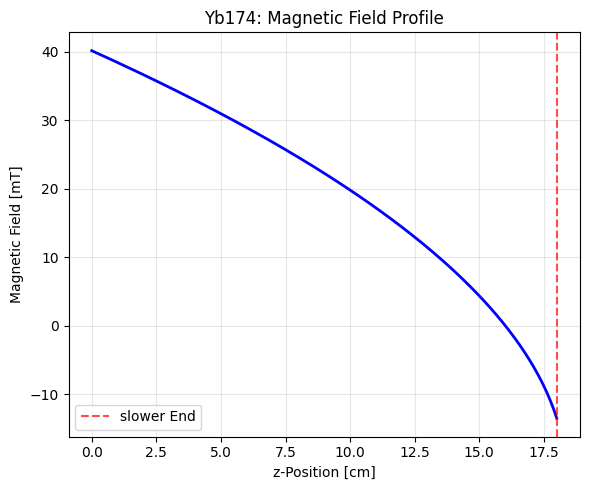

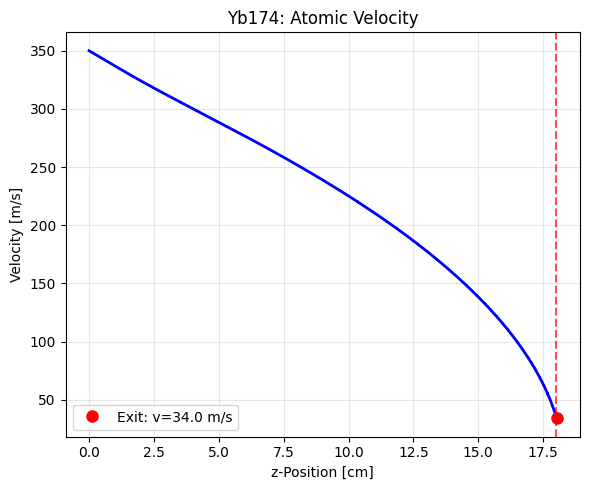

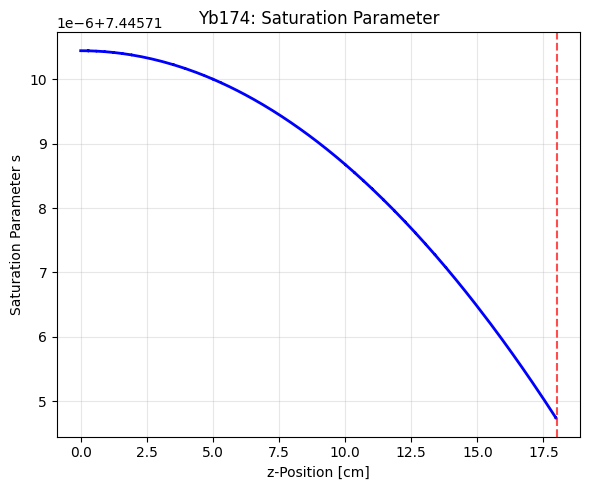

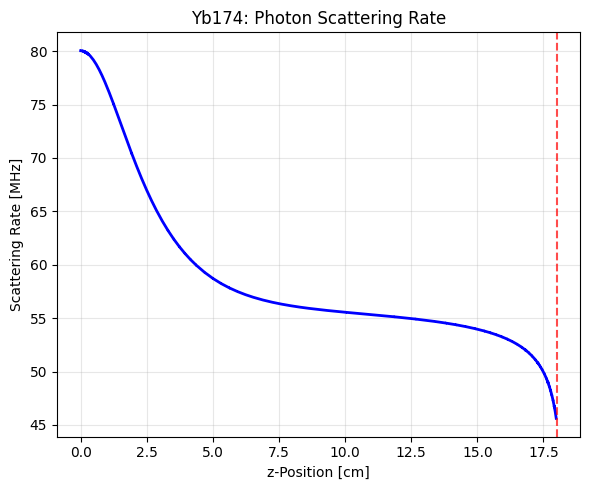

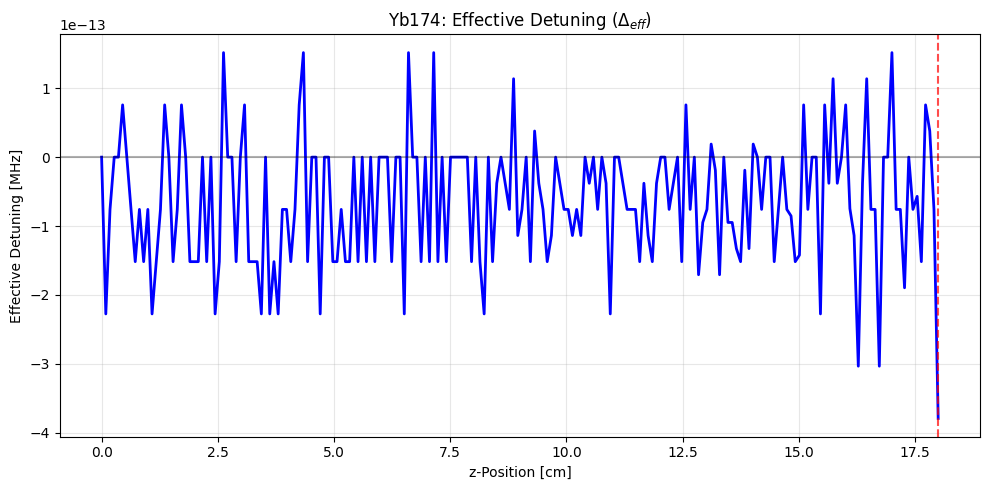

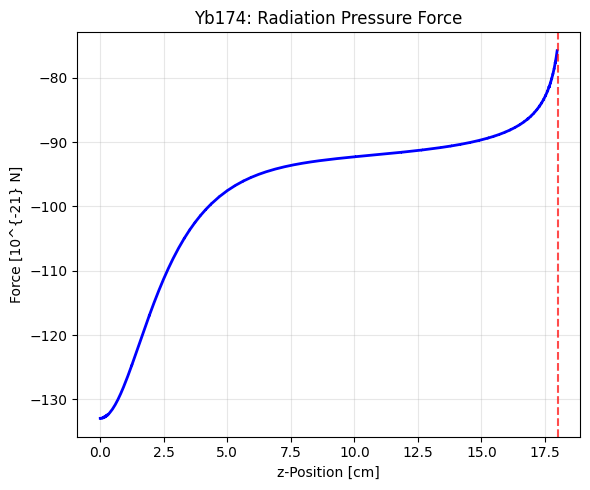

In [16]:
# Yb174 plots

# 1. magnetic field along ZS, changed units
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title('Yb174: Magnetic Field Profile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
plt.plot(z * 100, v, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)

if slower.has_exited:
  exit_z = slower.exit_position * 100
  exit_v = slower.exit_velocity
  plt.plot(exit_z, exit_v, 'ro', markersize=8, label=f'Exit: v={exit_v:.1f} m/s')

plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title('Yb174: Atomic Velocity')
plt.grid(True, alpha=0.3)

if slower.has_exited:
  plt.legend()

plt.tight_layout()
plt.show()

# 3. Saturation parameter along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.s_history, 'blue', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Saturation Parameter s')
plt.title('Yb174: Saturation Parameter')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Photon scattering rate along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.scattering_rate_history / 1e6, 'blue', linewidth=2)
plt.axvline(x = slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Scattering Rate [MHz]')
plt.title('Yb174: Photon Scattering Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. effective detuning
plt.figure(figsize=(10, 5))
z_detailed = np.linspace(0, slower_length, 200)
B_detailed = B_func(z_detailed)

# calculate required B-field for resonance (const deceleration)
v_resonance = np.sqrt(v0**2 + (v_final**2 - v0**2) * z_detailed / slower_length)

delta_effective = delta_laser + slower.k * v_resonance - (slower.mu_eff * B_detailed / slower.hbar)
plt.plot(z_detailed * 100, delta_effective / (2 * np.pi * 1e6), 'b-', linewidth=2)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title('Yb174: Effective Detuning ($\Delta_{eff}$)')
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
plt.plot(z * 100, slower.force_history * 1e21, 'b-', linewidth=2)  # Scale for better visibility
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title('Yb174: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## now simulate for 5000 Yb atoms

In [17]:
# Maxwell-Boltzmann PDF for speed
def maxwell_pdf(v, T, m):
    k_B = 1.380649e-23
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    k_B = 1.380649e-23
    sigma = np.sqrt(k_B*T/m)
    # Sample normally in 3D, take magnitude → EXACT MB speed distribution
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)


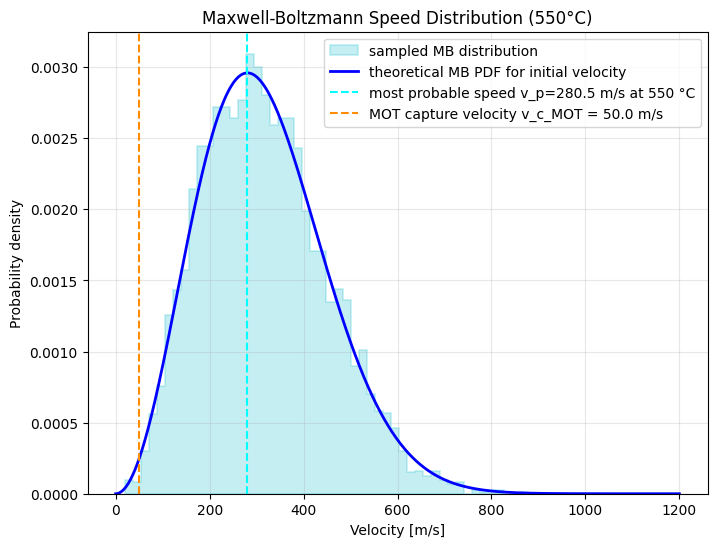

In [18]:
# 对比一下生成的和理论的
m = m_174 # check for Yb174
celcius = 550

T = 273.15 + celcius
n_samples = 5000
k_B = 1.380649e-23
v_p = np.sqrt(2*k_B*T/m)
v_c_MOT = 50

# sample velocities using correct MB distribution
velocities = sample_maxwell(T, m, n_samples)
# theoretical pdf curve
v_range = np.linspace(0, 1200, 1000)
f_v = maxwell_pdf(v_range, T, m)

plt.figure(figsize=(8, 6))
plt.hist(velocities,bins=50,density=True,histtype="stepfilled",color="tab:cyan",
         alpha=0.25,edgecolor="tab:cyan", linewidth=1.2, label="sampled MB distribution") # generated
plt.plot(v_range, f_v, 'b-', linewidth=2, label="theoretical MB PDF for initial velocity") # theoretical PDF
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {celcius} °C")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Maxwell-Boltzmann Speed Distribution ({celcius}°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


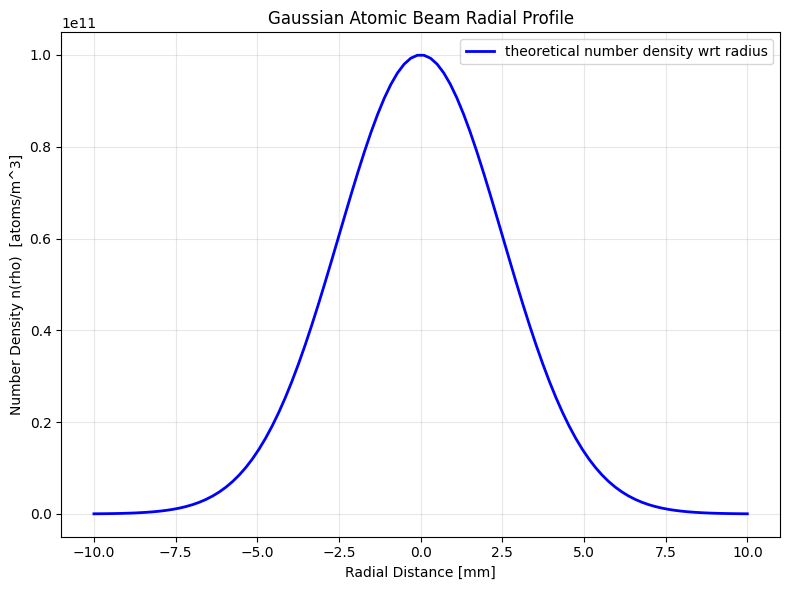

for the Yb atomic beam - 
  Most probable speed: v_p = 280.48 m/s
  RMS velocity: v_rms = 343.00 m/s
  Mean velocity: 316.68 m/s
  Standard deviation: 131.76 m/s
  Atom Beam waist: w_a = 5.0 mm 



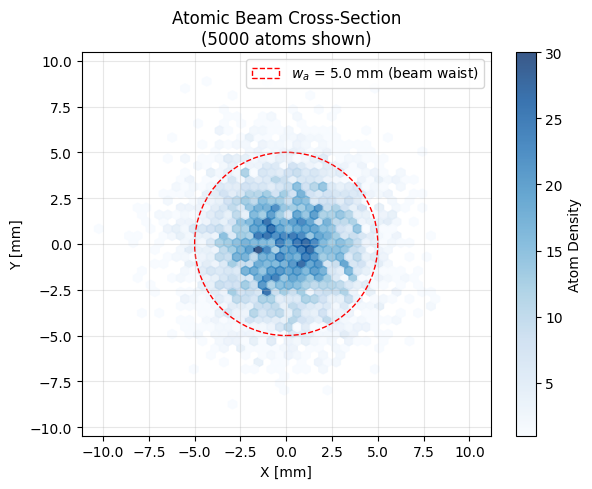

In [19]:
# number density: generate radial positions for Gaussian atomic beam
def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

# plot gaussian number density of the atoms
w_a = 5e-3  # 10mm diameter / 5mm waist
n0 = 10e10  # number density

plt.figure(figsize=(8, 6))
rho_range = np.linspace(-2*w_a, 2*w_a, 100)
n_rho = n0 * np.exp(-2 * rho_range**2 / w_a**2) # number density

plt.plot(rho_range*1000, n_rho, 'b-', linewidth=2, label='theoretical number density wrt radius')
plt.xlabel('Radial Distance [mm]')
plt.ylabel('Number Density n(rho)  [atoms/m^3]')
plt.title('Gaussian Atomic Beam Radial Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# check
print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

# DEBUG - visualize cross-section
def plot_beam_cross_section(rho_0_array, w_a, n_samples):
    ''' Visualize beam cross-section using 2D density plot '''
    theta = np.random.uniform(0, 2*np.pi, len(rho_0_array))
    x = rho_0_array * np.cos(theta)
    y = rho_0_array  * np.sin(theta)

    plt.figure(figsize=(6, 5))
    hexbin = plt.hexbin(x * 1000, y * 1000, gridsize=40, cmap='Blues',
                       alpha=0.8, mincnt=1)
    plt.colorbar(hexbin, label='Atom Density')
    # plot beam waist
    circle_1e2 = plt.Circle((0, 0), w_a * 1000, fill=False,
                           color='red', linewidth=1, linestyle='--',
                           label=f'$w_a$ = {w_a*1000:.1f} mm (beam waist)')
    plt.gca().add_patch(circle_1e2)

    plt.xlabel('X [mm]')
    plt.ylabel('Y [mm]')
    plt.title(f'Atomic Beam Cross-Section\n({len(rho_0_array)} atoms shown)')
    plt.axis('equal')
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)

    # Set axis limits to show full distribution
    max_radius = np.max(rho_0_array) * 1000
    axis_limit = max_radius * 1.1
    plt.xlim(-axis_limit, axis_limit)
    plt.ylim(-axis_limit, axis_limit)
    plt.tight_layout()
    plt.show()

# Plot the beam cross-section
plot_beam_cross_section(rho_0_array, w_a, n_samples)

In [25]:
# initialize storage for final velocities
final_velocities = np.zeros(n_samples)
exit_positions = np.zeros(n_samples)
exit_times = np.zeros(n_samples)
successful_slowing = np.zeros(n_samples, dtype=bool)

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
#new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)

#simulate for when there's no magnetic field
new_B_func = lambda z: np.zeros_like(z)

t_max = 0.02 # Maximum simulation time in seconds
n_points = 1000 # Number of time points for ODE integration

for i in range (n_samples):

    # get initial conditions for this atom
    z0 = 0.0  # all atoms start at z=0
    rho0 = rho_0_array[i]  # initial radial position
    v0 = velocities[i]     # initial velocity

    try:
        # run simulation for this atom
        t, z, v, rho = slower.simulate_slower(
            z0=z0, rho0=rho0, v0=v0,
            delta_laser=delta_laser,
            B_func=new_B_func, # here we calls the newly designed func matching v_p!!
            P_L=P_L, wL=wL,
            slower_length=slower_length,
            t_max=t_max, n_points=n_points)

        # store results if simulation successful
        final_velocities[i] = v[-1]  # final velocity
        exit_positions[i] = z[-1]    # final position
        exit_times[i] = t[-1]        # final time
        # boolean array to count successfully slowed instances
        successful_slowing[i] = (v[-1] <= v_c_MOT) and v[-1] > 0

    except Exception as e:
        # print(f"Error simulating atom {i}: {e}")
        final_velocities[i] = v0  # Keep initial velocity if simulation fails
        exit_positions[i] = 0.0
        exit_times[i] = 0.0
        successful_slowing[i] = False

# analyze results
print(f"=== Simulation Results ===")
print(f"Total atoms simulated: {n_samples}")
print(f"Successfully slowed (can be captured by MOT): {np.sum(successful_slowing)} ({np.mean(successful_slowing)*100:.1f}%)")
print(f"Final velocity statistics:")
print(f"  Mean: {np.mean(final_velocities):.2f} m/s")
print(f"  Std: {np.std(final_velocities):.2f} m/s")
print(f"  Min: {np.min(final_velocities):.2f} m/s")
print(f"  Max: {np.max(final_velocities):.2f} m/s")


=== Simulation Results ===
Total atoms simulated: 5000
Successfully slowed (can be captured by MOT): 301 (6.0%)
Final velocity statistics:
  Mean: 300.54 m/s
  Std: 154.89 m/s
  Min: -79.45 m/s
  Max: 878.49 m/s


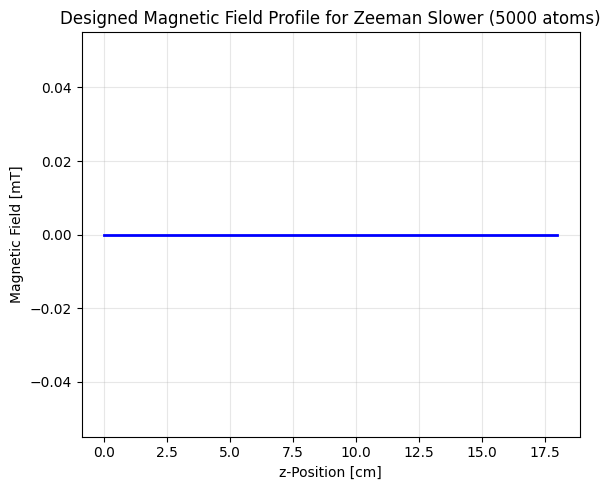

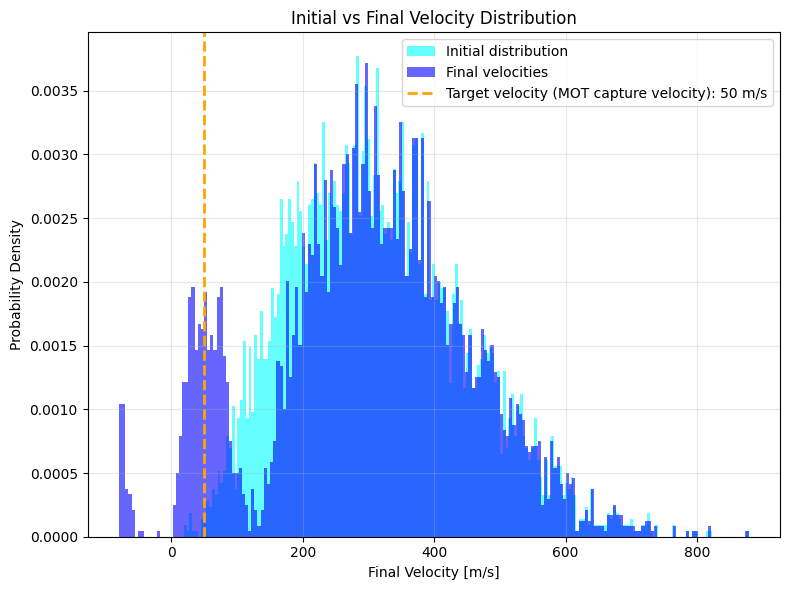

"\nplt.figure(figsize=(8,5))\nplt.hist(velocities, bins=200, density=True, alpha=0.6, color='cyan', label='Initial distribution')\nplt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2,\n           label=f'Target velocity (MOT capture velocity): {v_c_MOT} m/s')\nplt.xlabel('Velocity [m/s]')\nplt.ylabel('Probability Density')\nplt.title('Initial Velocity Distribution')\nplt.legend()\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()\n"

In [28]:
# plot designed B-field for Yb atoms
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = new_B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.xlabel("z-Position [cm]")
plt.ylabel("Magnetic Field [mT]")
plt.title(f"Designed Magnetic Field Profile for Zeeman Slower ({n_samples} atoms)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# plot final velocity distribution
plt.figure(figsize=(8, 6))

plt.hist(velocities, bins=200, density=True, alpha=0.6, color='cyan', label='Initial distribution')
plt.hist(final_velocities, bins=200, density=True, alpha=0.6, color='blue', label='Final velocities')
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2,
           label=f'Target velocity (MOT capture velocity): {v_c_MOT} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Initial vs Final Velocity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# plot initial velocity distribution
'''
plt.figure(figsize=(8,5))
plt.hist(velocities, bins=200, density=True, alpha=0.6, color='cyan', label='Initial distribution')
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2,
           label=f'Target velocity (MOT capture velocity): {v_c_MOT} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Initial Velocity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
'''


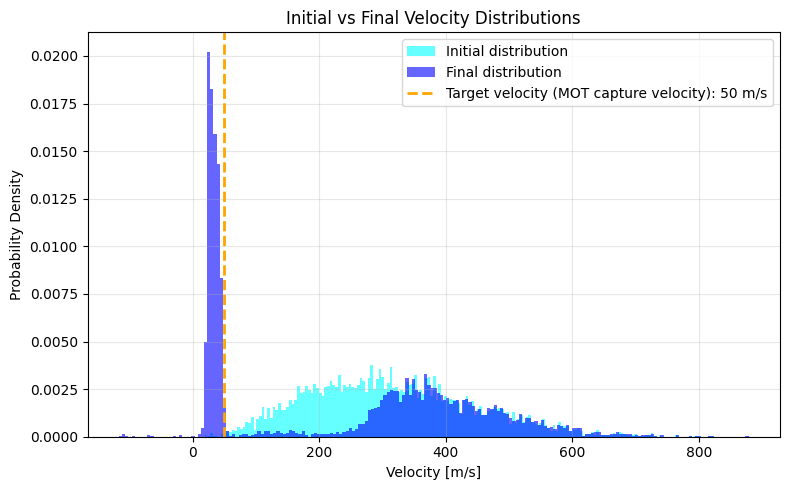

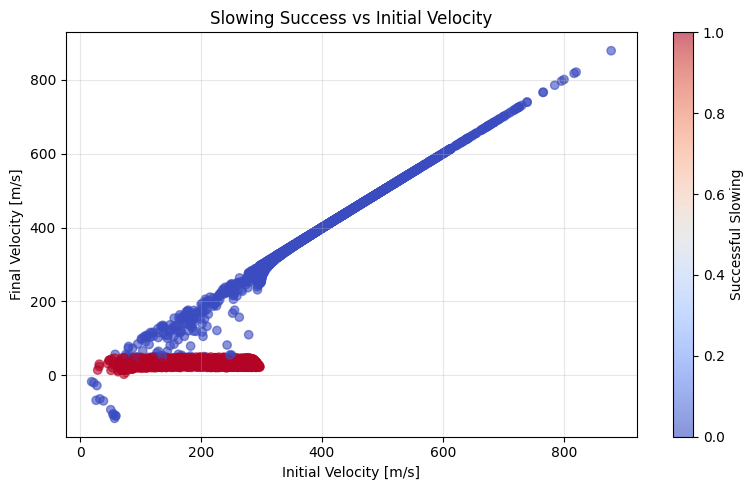

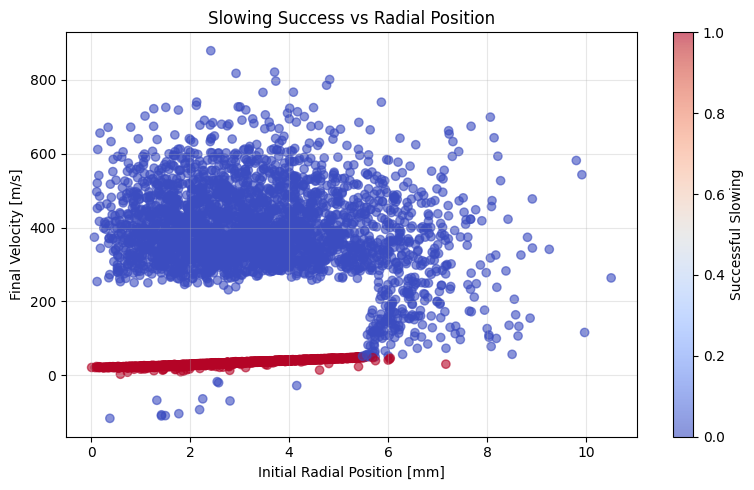

In [22]:
# Compare initial vs final distributions
plt.figure(figsize=(8,5))
plt.hist(velocities, bins=200, density=True, alpha=0.6, color='cyan', label='Initial distribution')
plt.hist(final_velocities, bins=200, density=True, alpha=0.6, color='blue', label='Final distribution')
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2,
           label=f'Target velocity (MOT capture velocity): {v_c_MOT} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Initial vs Final Velocity Distributions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# success vs initial velocity
plt.figure(figsize=(8,5))
sc = plt.scatter(velocities, final_velocities, c=successful_slowing,
                 cmap='coolwarm', alpha=0.6)

plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Success vs Initial Velocity')
plt.colorbar(label='Successful Slowing')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# success vs radial position
plt.figure(figsize=(8,5))
plt.scatter(rho_0_array * 1000, final_velocities, c=successful_slowing,
           cmap='coolwarm', alpha=0.6)
plt.xlabel('Initial Radial Position [mm]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Success vs Radial Position')
plt.colorbar(label='Successful Slowing')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


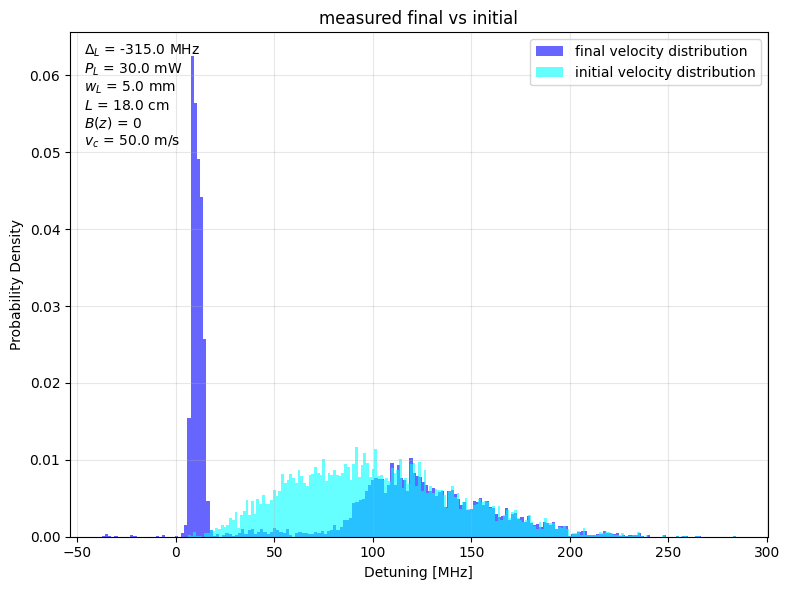

In [23]:
# measured

k_eff = (1 / 556e-9) * 0.18
detuning = k_eff * final_velocities

# plot final velocity distribution
plt.figure(figsize=(8, 6))
plt.hist(detuning / 1e6, bins=200, density=True, alpha=0.6, color='blue', label = 'final velocity distribution')
plt.hist((k_eff * velocities) / 1e6, bins=200, density=True, alpha=0.6, color='cyan', label = 'initial velocity distribution')

param_text = (
    rf"$\Delta_L$ = {delta_laser/(2*np.pi*1e6):.1f} MHz" "\n"
    rf"$P_L$ = {P_L*1e3:.1f} mW" "\n"
    rf"$w_L$ = {wL*1e3:.1f} mm" "\n"
    rf"$L$ = {slower_length*100:.1f} cm" "\n"
    rf"$B(z)$ = 0" "\n"
    rf"$v_c$ = {v_c_MOT:.1f} m/s"
)

plt.text(
    0.02, 0.98, param_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    #bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)


plt.xlabel('Detuning [MHz]')
plt.ylabel('Probability Density')
plt.title('measured final vs initial')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()